# Neuronas


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

In [8]:
# 1. Configuración de parámetros
np.random.seed(42)
n_puntos = 100
ruido = 0.15

# 2. Generación de puntos para la Clase 0 (Centros en (0,0) y (1,1))
clase_0 = np.concatenate(
    [
        np.random.normal(loc=[0, 0], scale=ruido, size=(n_puntos // 2, 2)),
        np.random.normal(loc=[1, 1], scale=ruido, size=(n_puntos // 2, 2)),
    ]
)

# 3. Generación de puntos para la Clase 1 (Centros en (0,1) y (1,0))
clase_1 = np.concatenate(
    [
        np.random.normal(loc=[0, 1], scale=ruido, size=(n_puntos // 2, 2)),
        np.random.normal(loc=[1, 0], scale=ruido, size=(n_puntos // 2, 2)),
    ]
)

print(clase_0.shape)
print(clase_1.shape)

(100, 2)
(100, 2)


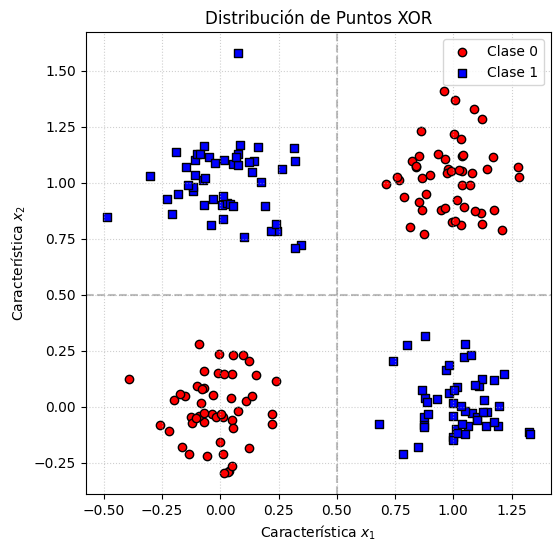

In [9]:
# 4. Graficación del patrón XOR
plt.figure(figsize=(6, 6))
plt.scatter(
    clase_0[:, 0], clase_0[:, 1], c="red", marker="o", label="Clase 0", edgecolors="k"
)
plt.scatter(
    clase_1[:, 0], clase_1[:, 1], c="blue", marker="s", label="Clase 1", edgecolors="k"
)

# Líneas de referencia para visualizar los cuadrantes
plt.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
plt.axvline(0.5, color="gray", linestyle="--", alpha=0.5)

plt.title("Distribución de Puntos XOR")
plt.xlabel("Característica $x_1$")
plt.ylabel("Característica $x_2$")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

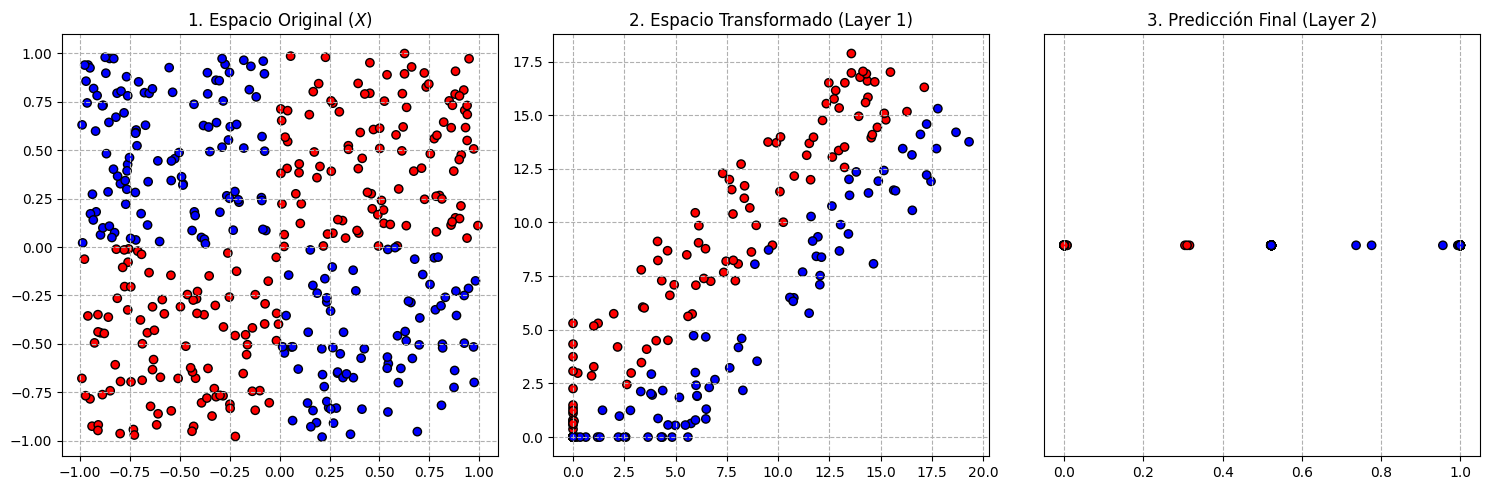

In [32]:
# 1. Función proporcionada para generar datos
def generate_xor_data(n=200):
    np.random.seed(42)
    x = np.random.uniform(-1, 1, (n, 2))
    y = np.logical_xor(x[:, 0] > 0, x[:, 1] > 0).astype(float)
    new_x = torch.tensor(x, dtype=torch.float32)
    new_y = torch.tensor(y, dtype=torch.float32).view(-1, 1)
    return new_x, new_y


X, Y = generate_xor_data(400)

# Colores para graficar: Rojo para 0, Azul para 1
colores = np.where(Y.numpy().flatten() == 0, "red", "blue")


# 2. Definición del modelo (2D a 2D a 1D)
class XORNet2D(nn.Module):
    def __init__(self, activacion_oculta=nn.Sigmoid()):
        """
        activacion_oculta: Función de activación de PyTorch (ej. nn.ReLU(), nn.Tanh())
        """
        super().__init__()
        self.capa_oculta = nn.Linear(2, 2)
        self.capa_salida = nn.Linear(2, 1)

        # Activación parametrizada para la deformación del espacio latente
        self.activacion_oculta = activacion_oculta

        # Activación fija para la salida (necesaria para clasificación binaria)
        self.activacion_salida = nn.Sigmoid()

    def forward(self, x):
        h = self.activacion_oculta(self.capa_oculta(x))
        y_pred = self.activacion_salida(self.capa_salida(h))
        return h, y_pred


# Ejemplos de instanciación:
# modelo = XORNet2D()
modelo = XORNet2D(activacion_oculta=nn.ReLU())  # pyright: ignore[reportArgumentType]
# modelo = XORNet2D(activacion_oculta=nn.Tanh()) # pyright: ignore[reportArgumentType]
optimizer = optim.Adam(modelo.parameters(), lr=0.1)
criterion = nn.BCELoss()

# 3. Entrenamiento
for epoch in range(2500):
    optimizer.zero_grad()
    h, y_pred = modelo(X)
    loss = criterion(y_pred, Y)
    loss.backward()
    optimizer.step()

# 4. Extracción de los espacios transformados
with torch.no_grad():
    H_tensor, Y_pred_tensor = modelo(X)

X_np = X.numpy()
H_np = H_tensor.numpy()
Y_pred_np = Y_pred_tensor.numpy()

# 5. Graficación secuencial
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].scatter(X_np[:, 0], X_np[:, 1], c=colores, edgecolors="k")
axs[0].set_title("1. Espacio Original ($X$)")
axs[0].grid(True, linestyle="--")

axs[1].scatter(H_np[:, 0], H_np[:, 1], c=colores, edgecolors="k")
axs[1].set_title("2. Espacio Transformado (Layer 1)")
axs[1].grid(True, linestyle="--")

# Se plotea en Y=0 para visualizar la separación en una dimensión
axs[2].scatter(
    Y_pred_np[:, 0], np.zeros_like(Y_pred_np[:, 0]), c=colores, edgecolors="k"
)
axs[2].set_title("3. Predicción Final (Layer 2)")
axs[2].set_yticks([])
axs[2].grid(True, linestyle="--")

plt.tight_layout()
plt.show()